In [10]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the Excel file
df = pd.read_excel("student_survey.xlsx")

# Rename the long Google Form questions to match the lab requirements
df = df.rename(columns={
    'your CIA % of last semester ': 'CIA Percentage',
    'Your maximum attendance % till last semester': 'Attendance Percentage',
    'your GPA of last semester': 'GPA'
})

# Display the first 5 rows
df[["CIA Percentage", "Attendance Percentage", "GPA"]].head()

,CIA Percentage,Attendance Percentage,GPA
0,78,Option 1,3.24
1,64.78,Option 1,3.2
2,80,Option 1,3.6
3,70,92,3.2
4,68,85,3.4


In [11]:
# Check rows and columns
print(f"Dataset Dimensions (Rows, Columns): {df.shape}")

Dataset Dimensions (Rows, Columns): (54, 15)


In [12]:
# Check for missing values
print("Missing values before cleaning:")
print(df[["CIA Percentage", "Attendance Percentage", "GPA"]].isnull().sum())

# Drop rows with missing values in our target columns
df = df.dropna(subset=["CIA Percentage", "Attendance Percentage", "GPA"])

Missing values before cleaning:
CIA Percentage           0
Attendance Percentage    0
GPA                      0
dtype: int64


# Force columns to be numerical (converts errors to NaN, then drops them)
cols = ["CIA Percentage", "Attendance Percentage", "GPA"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=cols)

# Remove duplicate records
df = df.drop_duplicates(subset=cols)
print(f"Dimensions after cleaning: {df.shape}")

In [14]:
# Show statistical summary (mean, max, min, etc.)
df[cols].describe()

,CIA Percentage,Attendance Percentage,GPA
count,46.000000,46.000000,46.000000
mean,58.326763,79.100402,5.623913
std,30.939425,33.757066,12.769951
min,0.630000,0.870000,2.900000
25%,65.002500,86.250000,3.400000
50%,70.000000,92.000000,3.505000
75%,78.000000,96.750000,3.730000
max,89.000000,100.000000,90.000000


Experiment 1: CIA Percentage vs GPA
Select variables and split the dataset

In [15]:
# Select variables for Experiment 1
X1 = df[["CIA Percentage"]]
y1 = df["GPA"]

# Split into 80% training and 20% testing
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
print("Data split complete for Experiment 1.")

Data split complete for Experiment 1.


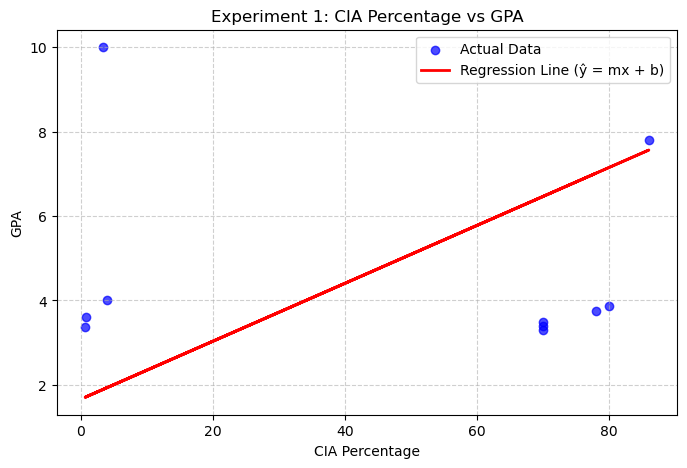

In [21]:
import matplotlib.pyplot as plt

# Create the plot window
plt.figure(figsize=(8, 5))

# 1. Plot the actual testing data points as a scatter plot
plt.scatter(X1_test, y1_test, color='blue', label='Actual Data', alpha=0.7)

# 2. Plot the predicted regression line (Using Scikit-Learn or Manual predictions)
plt.plot(X1_test, sk_pred1, color='red', linewidth=2, label='Regression Line (ŷ = mx + b)')

# Add labels and styling
plt.title('Experiment 1: CIA Percentage vs GPA')
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the graph
plt.show()

In [16]:
# Select variables for Experiment 2
X2 = df[["Attendance Percentage"]]
y2 = df["GPA"]

# Split into 80% training and 20% testing
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
print("Data split complete for Experiment 2.")

Data split complete for Experiment 2.


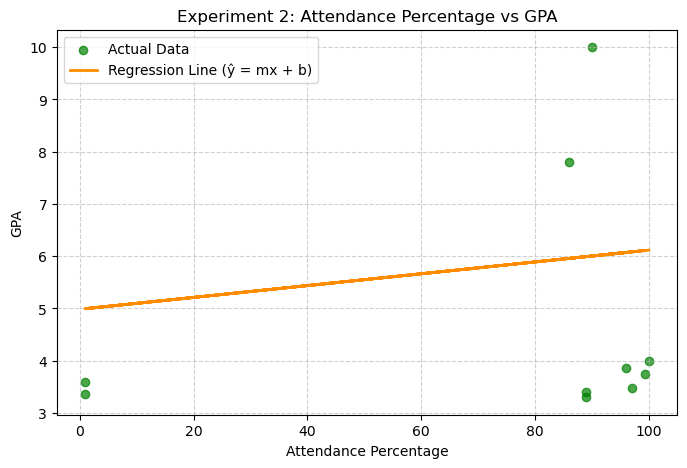

In [22]:
import matplotlib.pyplot as plt

# Create the plot window
plt.figure(figsize=(8, 5))

# 1. Plot the actual testing data points as a scatter plot
plt.scatter(X2_test, y2_test, color='green', label='Actual Data', alpha=0.7)

# 2. Plot the predicted regression line
plt.plot(X2_test, sk_pred2, color='darkorange', linewidth=2, label='Regression Line (ŷ = mx + b)')

# Add labels and styling
plt.title('Experiment 2: Attendance Percentage vs GPA')
plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the graph
plt.show()

## Data Visualization: Plotting the Regression Lines

To visually evaluate our models, we plot the actual ground-truth testing data points alongside our computed best-fit regression lines. This helps us observe the variance and linear distribution of:
1. **CIA Percentage vs GPA**
2. **Attendance Percentage vs GPA**

In [17]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

# Obtain parameters and predict
sk_slope2 = model2.coef_[0]
sk_intercept2 = model2.intercept_
sk_pred2 = model2.predict(X2_test)

print(f"Scikit-Learn Slope (m): {sk_slope2:.4f}")
print(f"Scikit-Learn Intercept (b): {sk_intercept2:.4f}")

Scikit-Learn Slope (m): 0.0113
Scikit-Learn Intercept (b): 4.9843


## Part B: Simple Linear Regression using Scikit-learn

In this section, we implement the standard machine learning pipeline using the `scikit-learn` library to perform linear regression:

1. Train-Test Split: Separate the cleaned dataset into training (80%) and testing (20%) sets to ensure proper validation.
2. Model Training: Initialize and fit the `LinearRegression` estimator using the training data split.
3. Parameter Extraction: Retrieve the optimized weights learned by the model:
   * **Slope ($m$ / Coef_)**
   * **Intercept ($b$ / Intercept_)**
4. Prediction: Use the trained model parameters to predict the target values ($\hat{y}$) for the unseen test inputs.

In [18]:
# Flatten data for manual math
x2_m = X2_train.values.flatten()
y2_m = y2_train.values

# Calculate means
x2_mean = np.mean(x2_m)
y2_mean = np.mean(y2_m)

# Apply OLS Equations
m2_manual = np.sum((x2_m - x2_mean) * (y2_m - y2_mean)) / np.sum((x2_m - x2_mean) ** 2)
b2_manual = y2_mean - (m2_manual * x2_mean)

# Generate predictions manually
manual_pred2 = (m2_manual * X2_test.values.flatten()) + b2_manual

print(f"Manual OLS Slope (m): {m2_manual:.4f}")
print(f"Manual OLS Intercept (b): {b2_manual:.4f}")
print(f"Manual Equation: ŷ = {m2_manual:.4f}x + {b2_manual:.4f}")

Manual OLS Slope (m): 0.0113
Manual OLS Intercept (b): 4.9843
Manual Equation: ŷ = 0.0113x + 4.9843


In [19]:
# Compare outputs and display differences
comp_df2 = pd.DataFrame({
    'Actual GPA': y2_test.values,
    'Sklearn Prediction': sk_pred2,
    'Manual Prediction': manual_pred2,
    'Absolute Difference': np.abs(sk_pred2 - manual_pred2)
})
comp_df2.head()

,Actual GPA,Sklearn Prediction,Manual Prediction,Absolute Difference
0,4.00,6.116182,6.116182,0.0
1,3.60,4.995232,4.995232,0.0
2,3.86,6.070905,6.070905,0.0
3,7.80,5.957712,5.957712,0.0
4,3.30,5.991670,5.991670,0.0


## Comparison Task & Observations

In this section, we compare the prediction outputs generated by the two distinct approaches:
1. **Scikit-Learn Predictions:** Evaluated using the `.predict()` method on the trained library model.
2. **Manual OLS Predictions:** Computed using the mathematically derived regression equation ($\hat{y} = mx + b$).
3. **Absolute Difference:** The element-wise variation ($|\text{Scikit-Learn} - \text{Manual}|$) between both output matrices to verify mathematical alignment.

In [20]:
# Save weights to file (using a unique name for Experiment 2)
weights2 = {'slope': sk_slope2, 'intercept': sk_intercept2}
with open("attendance_regression_weights.pkl", "wb") as f:
    pickle.dump(weights2, f)
print("Saved parameters to 'attendance_regression_weights.pkl'")

# Load and test prediction
with open("attendance_regression_weights.pkl", "rb") as f:
    loaded_w2 = pickle.load(f)
    
test_val2 = X2_test.values[0][0]
pred_val2 = (loaded_w2['slope'] * test_val2) + loaded_w2['intercept']
print(f"Loaded model prediction for Attendance {test_val2}%: {pred_val2:.2f}")

Saved parameters to 'attendance_regression_weights.pkl'
Loaded model prediction for Attendance 100.0%: 6.12
